In [4]:
from sklearn import tree
import pandas as pd
from model_train_for_presentation import create_diff
from sklearn.model_selection import train_test_split


df = pd.read_csv("../training_data/training_data.csv")
stats_list = [
        "AdjOE", "AdjDE", "EFG%", "EFGD%", "TOR", "TORD",
        "ORB", "DRB", "ADJ T", "WAB"
    ]
training_df = create_diff(df, stats_list)

X = training_df.drop("y", axis=1)
y = training_df["y"]

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80/20 split
    random_state=42,
    stratify=y            # important for classification
)

clf = tree.DecisionTreeClassifier(max_depth=3,class_weight = "balanced",  random_state=42)
clf = clf.fit(X_train, y_train)


Precision: 0.6491228070175439
Recall: 0.7184466019417476
F1 Score: 0.6820276497695853
AUC-ROC: 0.7672992056487202
Brier Score: 0.19707148974343316
Log Loss: 0.5760662742460826


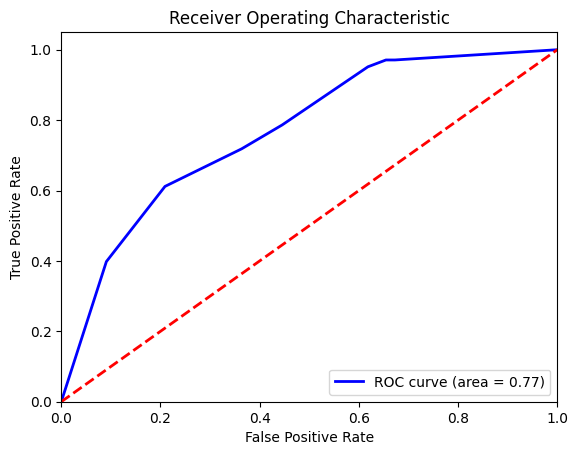

['tree_depth3.pkl']

In [5]:
#get precision, recall, and f1 score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, brier_score_loss, log_loss
y_pred_orig = clf.predict(X_test)
y_prob_orig = clf.predict_proba(X_test)[:, 1]
precision = precision_score(y_test, y_pred_orig)
recall = recall_score(y_test, y_pred_orig)
f1 = f1_score(y_test, y_pred_orig)
auc_roc = roc_auc_score(y_test, y_prob_orig)
brier = brier_score_loss(y_test, y_prob_orig)
logloss = log_loss(y_test, y_prob_orig)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"AUC-ROC: {auc_roc}")
print(f"Brier Score: {brier}")
print(f"Log Loss: {logloss}")

#Plot some of these things: 
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_prob_orig)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

import joblib
joblib.dump(clf, "tree_depth3.pkl")


In [6]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(clf, X, y, cv=5, scoring="neg_log_loss")
print("Avg Log Loss:", -scores.mean())


Avg Log Loss: 0.569482044026218


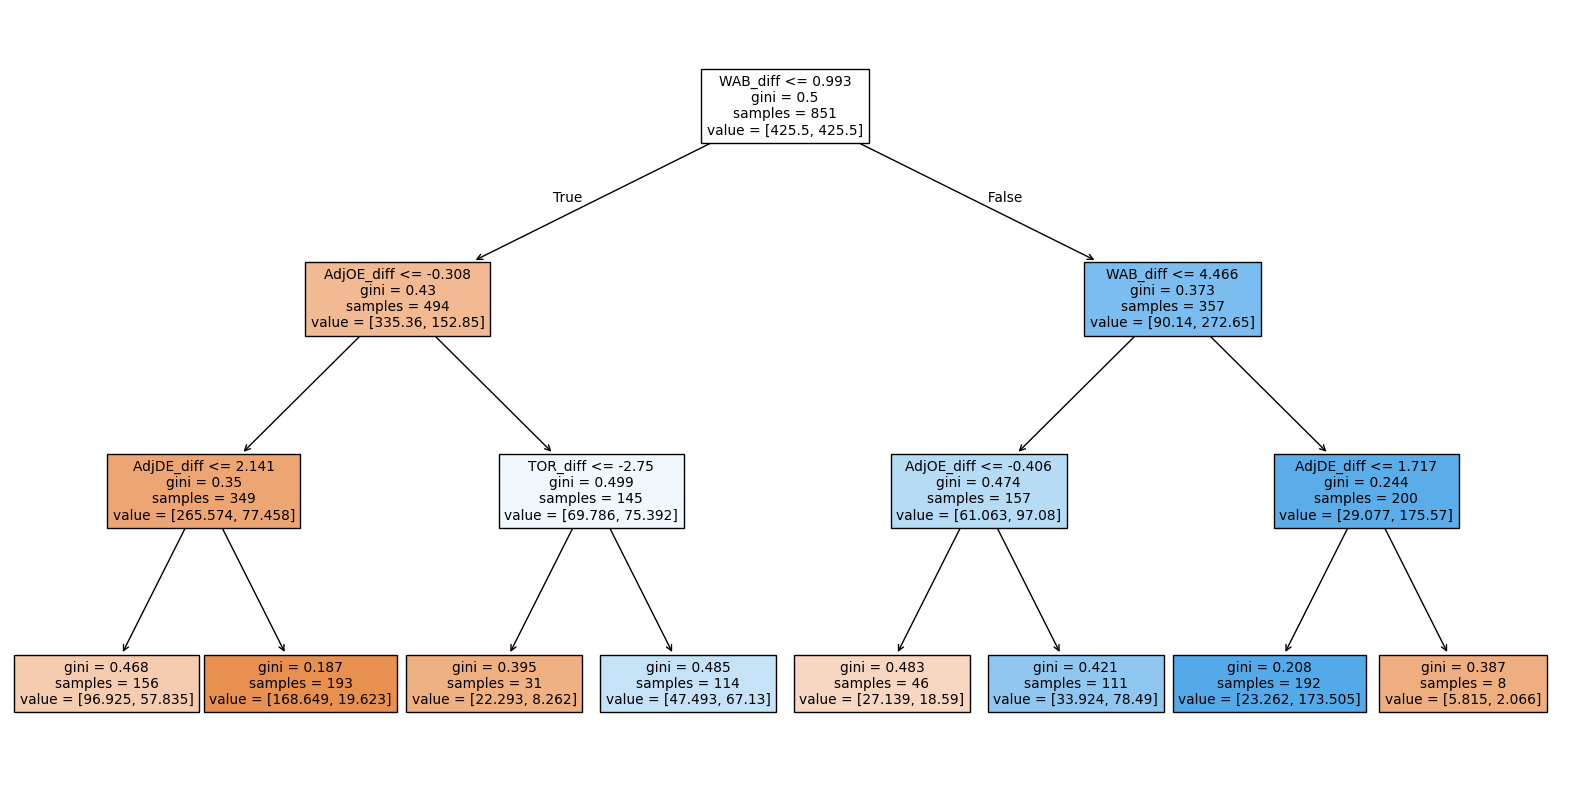

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(clf, filled=True, feature_names=X.columns)
plt.savefig("tree.pdf")



In [8]:
from sklearn.tree import export_text

print(export_text(clf, feature_names=list(X.columns)))

|--- WAB_diff <= 0.99
|   |--- AdjOE_diff <= -0.31
|   |   |--- AdjDE_diff <= 2.14
|   |   |   |--- class: 0
|   |   |--- AdjDE_diff >  2.14
|   |   |   |--- class: 0
|   |--- AdjOE_diff >  -0.31
|   |   |--- TOR_diff <= -2.75
|   |   |   |--- class: 0
|   |   |--- TOR_diff >  -2.75
|   |   |   |--- class: 1
|--- WAB_diff >  0.99
|   |--- WAB_diff <= 4.47
|   |   |--- AdjOE_diff <= -0.41
|   |   |   |--- class: 0
|   |   |--- AdjOE_diff >  -0.41
|   |   |   |--- class: 1
|   |--- WAB_diff >  4.47
|   |   |--- AdjDE_diff <= 1.72
|   |   |   |--- class: 1
|   |   |--- AdjDE_diff >  1.72
|   |   |   |--- class: 0



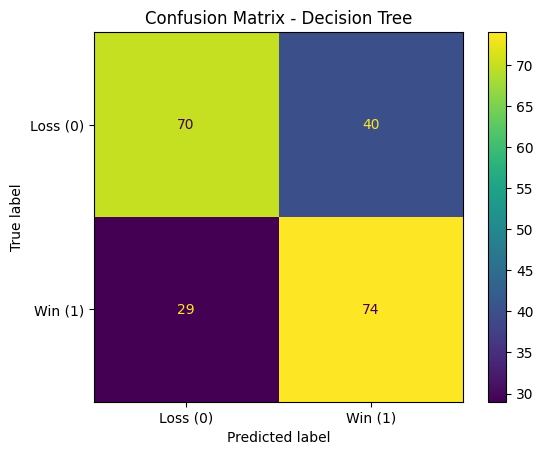

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = clf.predict(X_test)

disp = ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test,
    y_test,
    display_labels=["Loss (0)", "Win (1)"]
)

plt.title("Confusion Matrix - Decision Tree")
plt.show()

#Tune Maximum Depth and CCP:

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

param_grid = {
    "max_depth": range(1, 21),
    "ccp_alpha": ccp_alphas #[0.0, 1e-4, 1e-3, 1e-2, 1e-1]
}

clf = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

grid = GridSearchCV(
    clf,
    param_grid=param_grid,
    cv=5,                 # 5-fold cross validation
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'ccp_alpha': np.float64(0.005230032403945446), 'max_depth': 4}
Best CV score: 0.7156243550051601


In [11]:
print(f"Max ccp_alpha: {grid.best_params_['ccp_alpha']}")
print(f"Max depth: {grid.best_params_['max_depth']}")

best_depth = grid.best_params_["max_depth"]
best_alpha = grid.best_params_["ccp_alpha"]

Max ccp_alpha: 0.005230032403945446
Max depth: 4


Test accuracy: 0.6713615023474179


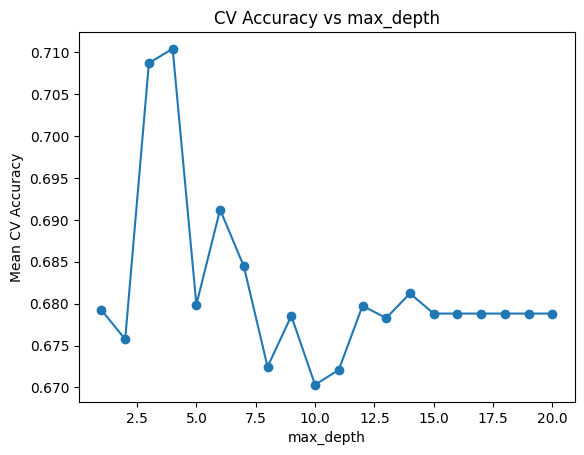

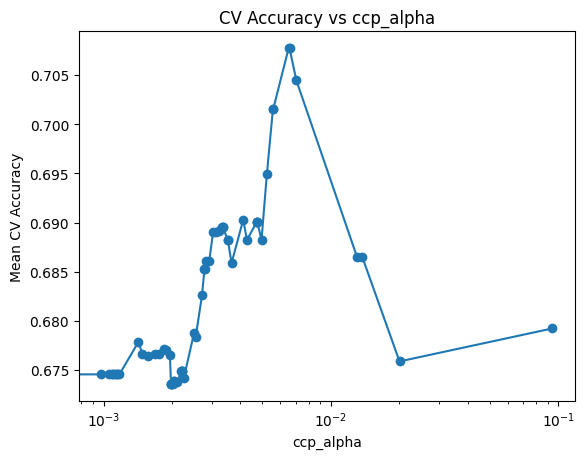

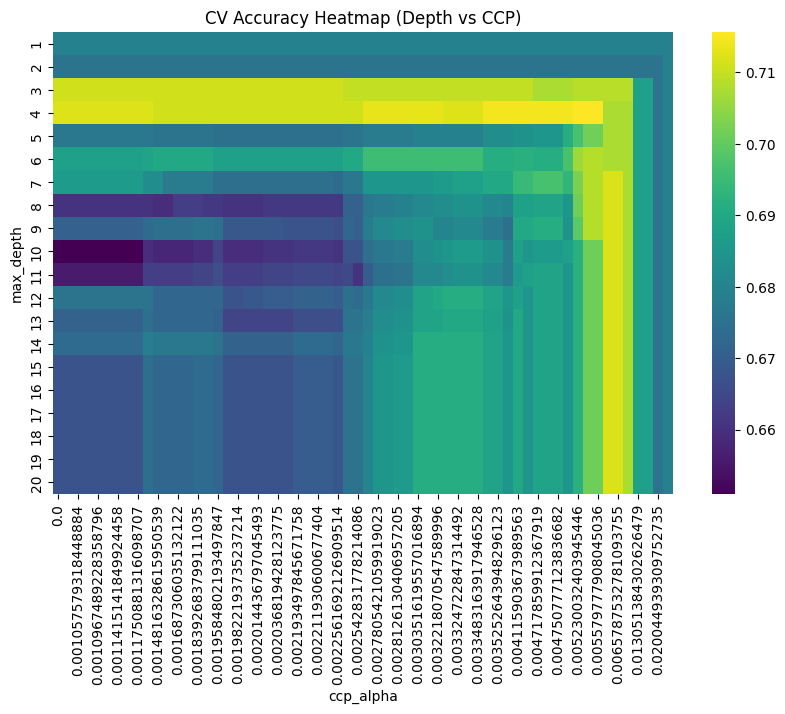

In [12]:
final_clf = grid.best_estimator_
final_clf.fit(X_train, y_train)

print("Test accuracy:", final_clf.score(X_test, y_test))


results = pd.DataFrame(grid.cv_results_)
depth_scores = results.groupby("param_max_depth")["mean_test_score"].mean()

plt.figure()
plt.plot(depth_scores.index, depth_scores.values, marker="o")
plt.xlabel("max_depth")
plt.ylabel("Mean CV Accuracy")
plt.title("CV Accuracy vs max_depth")
plt.show()

ccp_scores = results.groupby("param_ccp_alpha")["mean_test_score"].mean()

plt.figure()
plt.plot(ccp_scores.index, ccp_scores.values, marker="o")
plt.xscale("log")  # important because alphas are usually log-spaced
plt.xlabel("ccp_alpha")
plt.ylabel("Mean CV Accuracy")
plt.title("CV Accuracy vs ccp_alpha")
plt.show()

import seaborn as sns

pivot = results.pivot_table(
    values="mean_test_score",
    index="param_max_depth",
    columns="param_ccp_alpha"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=False, cmap="viridis")
plt.xlabel("ccp_alpha")
plt.ylabel("max_depth")
plt.title("CV Accuracy Heatmap (Depth vs CCP)")
plt.show()

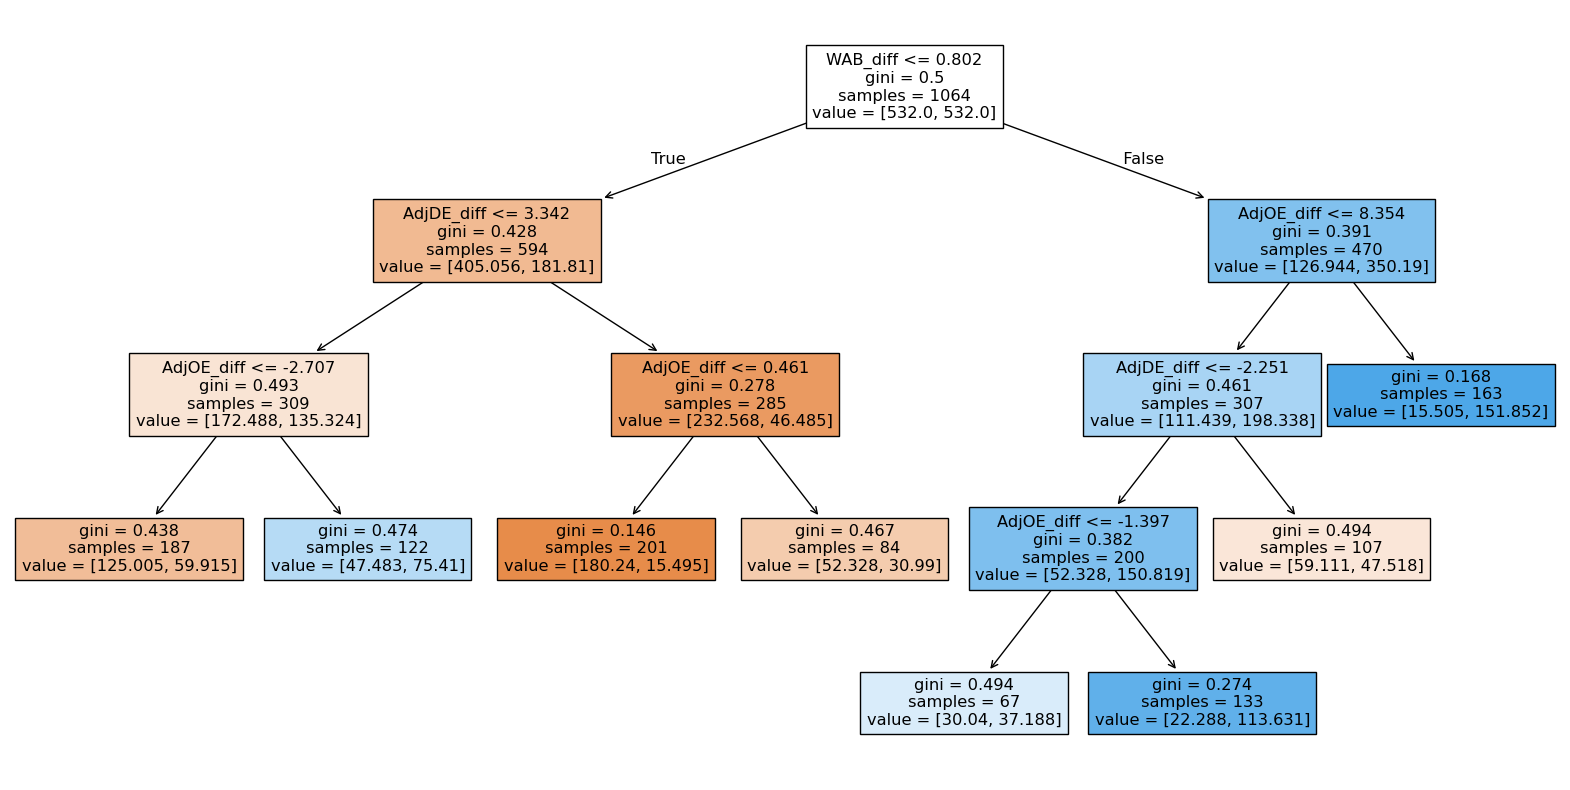

In [17]:
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.tree import export_text

both_tuned_clf = tree.DecisionTreeClassifier(
    max_depth=best_depth,
    ccp_alpha=best_alpha,
    class_weight="balanced",
    random_state=42
)

both_tuned_clf.fit(X, y)
plt.figure(figsize=(20,10))
tree.plot_tree(
    both_tuned_clf,
    filled=True,
    feature_names=X.columns
)

plt.savefig("both_tuned_tree.pdf")
plt.show()

In [14]:
from sklearn.tree import export_text

print(export_text(both_tuned_clf, feature_names=list(X.columns)))

|--- WAB_diff <= 0.80
|   |--- AdjDE_diff <= 3.34
|   |   |--- AdjOE_diff <= -2.71
|   |   |   |--- class: 0
|   |   |--- AdjOE_diff >  -2.71
|   |   |   |--- class: 1
|   |--- AdjDE_diff >  3.34
|   |   |--- AdjOE_diff <= 0.46
|   |   |   |--- class: 0
|   |   |--- AdjOE_diff >  0.46
|   |   |   |--- class: 0
|--- WAB_diff >  0.80
|   |--- AdjOE_diff <= 8.35
|   |   |--- AdjDE_diff <= -2.25
|   |   |   |--- AdjOE_diff <= -1.40
|   |   |   |   |--- class: 1
|   |   |   |--- AdjOE_diff >  -1.40
|   |   |   |   |--- class: 1
|   |   |--- AdjDE_diff >  -2.25
|   |   |   |--- class: 0
|   |--- AdjOE_diff >  8.35
|   |   |--- class: 1



Precision: 0.7333333333333333
Recall: 0.7475728155339806
F1 Score: 0.7403846153846154
AUC-ROC: 0.8157546337157988
Brier Score: 0.17290368980455686
Log Loss: 0.5176923776705936


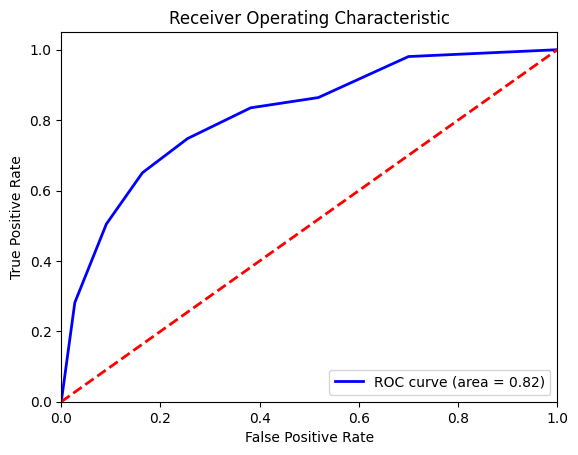

['tree_depth3_both.pkl']

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, brier_score_loss, log_loss
y_pred_both = both_tuned_clf.predict(X_test)
y_prob_both = both_tuned_clf.predict_proba(X_test)[:, 1]
precision = precision_score(y_test, y_pred_both)
recall = recall_score(y_test, y_pred_both)
f1 = f1_score(y_test, y_pred_both)
auc_roc = roc_auc_score(y_test, y_prob_both)
brier = brier_score_loss(y_test, y_prob_both)
logloss = log_loss(y_test, y_prob_both)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"AUC-ROC: {auc_roc}")
print(f"Brier Score: {brier}")
print(f"Log Loss: {logloss}")

#Plot some of these things: 
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_prob_both)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

joblib.dump(both_tuned_clf, "tree_depth3_both.pkl")

In [31]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(both_tuned_clf, X, y, cv=5, scoring="neg_log_loss")
print("Avg Log Loss:", -scores.mean())


Avg Log Loss: 0.5683324987726541


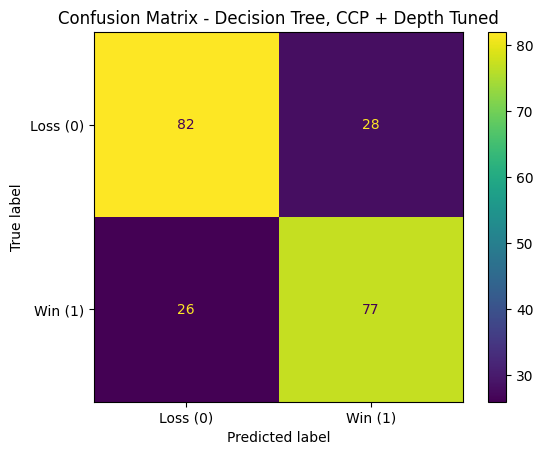

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = both_tuned_clf.predict(X_test)

disp = ConfusionMatrixDisplay.from_estimator(
    both_tuned_clf,
    X_test,
    y_test,
    display_labels=["Loss (0)", "Win (1)"]
)

plt.title("Confusion Matrix - Decision Tree, CCP + Depth Tuned")
plt.show()

#Just tuning ccp:

Best ccp_alpha: 0.0035694145247082715


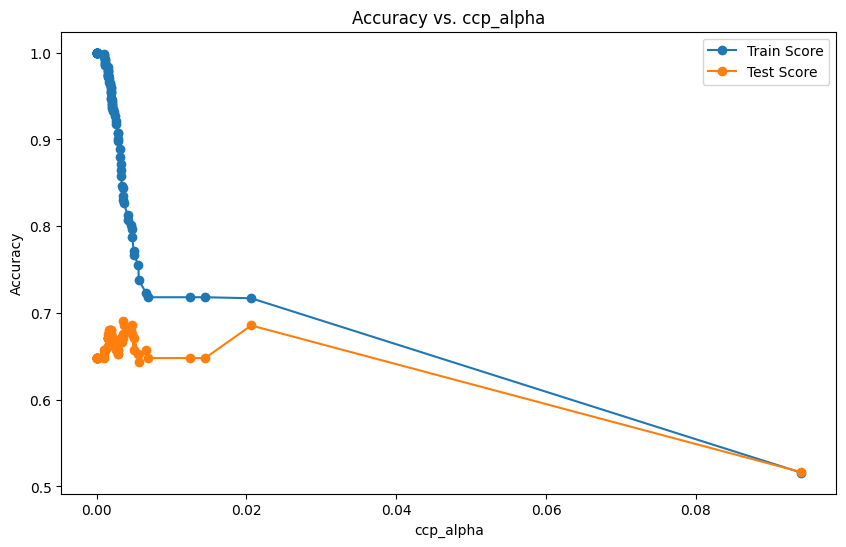

In [20]:
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

models = []
for alpha in ccp_alphas:
    model = tree.DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha,
        class_weight="balanced"
    )
    model.fit(X_train, y_train)
    models.append(model)

train_scores = [model.score(X_train, y_train) for model in models]
test_scores = [model.score(X_test, y_test) for model in models]

#Get the best alpha:
best_alpha = ccp_alphas[test_scores.index(max(test_scores))]
print("Best ccp_alpha:", best_alpha)

plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train Score')
plt.plot(ccp_alphas, test_scores, marker='o', label='Test Score')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs. ccp_alpha')
plt.show()


|--- WAB_diff <= 0.80
|   |--- AdjDE_diff <= 3.34
|   |   |--- AdjOE_diff <= -2.71
|   |   |   |--- class: 0
|   |   |--- AdjOE_diff >  -2.71
|   |   |   |--- class: 1
|   |--- AdjDE_diff >  3.34
|   |   |--- AdjOE_diff <= 0.46
|   |   |   |--- class: 0
|   |   |--- AdjOE_diff >  0.46
|   |   |   |--- class: 0
|--- WAB_diff >  0.80
|   |--- AdjOE_diff <= 8.35
|   |   |--- AdjDE_diff <= -2.25
|   |   |   |--- class: 1
|   |   |--- AdjDE_diff >  -2.25
|   |   |   |--- class: 0
|   |--- AdjOE_diff >  8.35
|   |   |--- AdjDE_diff <= 7.35
|   |   |   |--- class: 1
|   |   |--- AdjDE_diff >  7.35
|   |   |   |--- class: 0



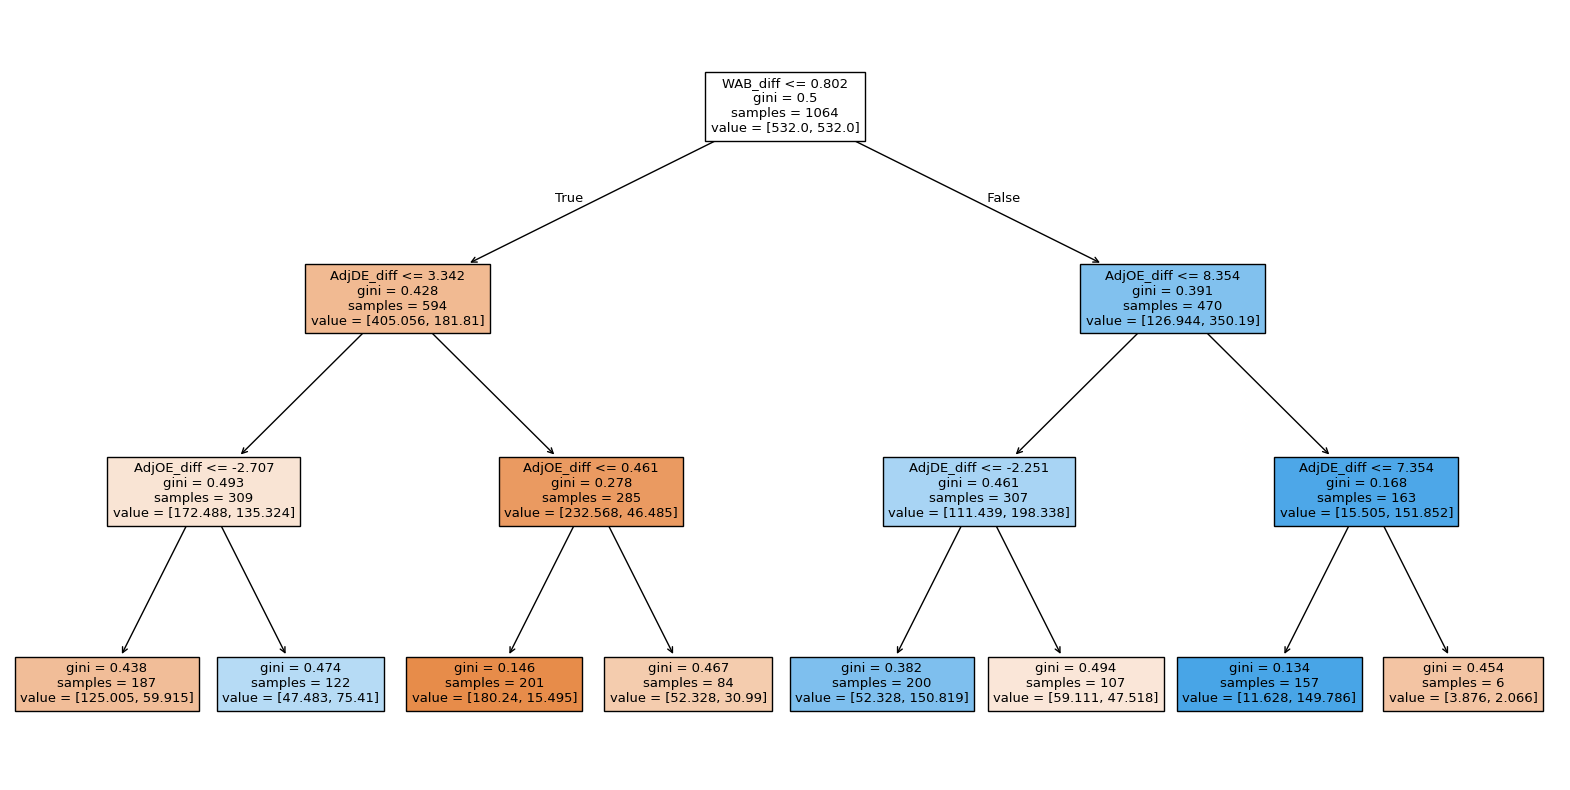

In [21]:
#Final model with best alpha:
final_clf = tree.DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=best_alpha,
    class_weight="balanced",
    max_depth=3
)
final_clf.fit(X, y) #Note, we fit on the whole dataset here, not just the training set, since we are doing cross-validation to find the best alpha.
#Interpret the tree:
plt.figure(figsize=(20,10))
tree.plot_tree(final_clf, filled=True, feature_names=X.columns)
plt.savefig("final_tree.pdf")

from sklearn.tree import export_text
#rename class names to "Team A Wins" (1) and "Team A loses (0)
# final_clf.classes_ = ["Team A loses", "Team A wins"]
print(export_text(final_clf, feature_names=list(X.columns)))

Precision: 0.7307692307692307
Recall: 0.7378640776699029
F1 Score: 0.7342995169082126
AUC-ROC: 0.7976169461606354
Brier Score: 0.17960542859219236
Log Loss: 0.532813804588231


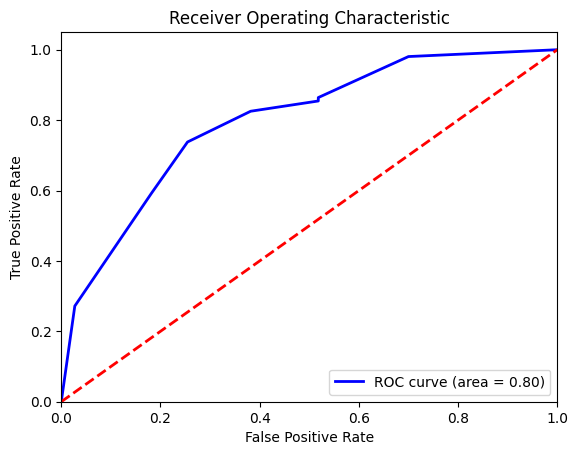

['tree_depth3_justccp.pkl']

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, brier_score_loss, log_loss
y_pred = final_clf.predict(X_test)
y_prob = final_clf.predict_proba(X_test)[:, 1]
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)
logloss = log_loss(y_test, y_prob)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"AUC-ROC: {auc_roc}")
print(f"Brier Score: {brier}")
print(f"Log Loss: {logloss}")

#Plot some of these things: 
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

joblib.dump(final_clf, "tree_depth3_justccp.pkl")

In [36]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(final_clf, X, y, cv=5, scoring="neg_log_loss")
print("Avg Log Loss:", -scores.mean())


Avg Log Loss: 0.5676560685469205


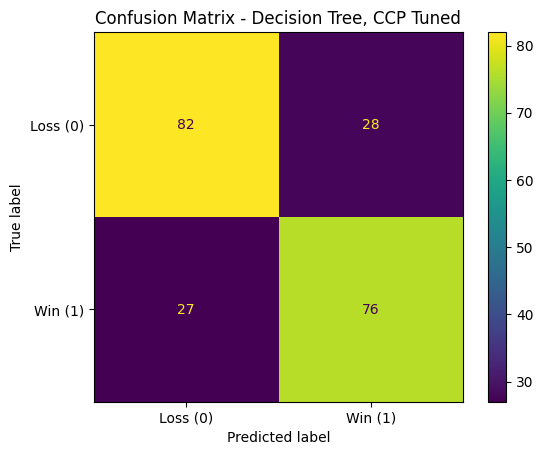

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = final_clf.predict(X_test)

disp = ConfusionMatrixDisplay.from_estimator(
    final_clf,
    X_test,
    y_test,
    display_labels=["Loss (0)", "Win (1)"]
)

plt.title("Confusion Matrix - Decision Tree, CCP Tuned")
plt.show()

Primary driver:
Overall strength (WAB_diff)
Secondary drivers:
Offensive efficiency (AdjOE_diff)
Defensive efficiency (AdjDE_diff)

But with nonlinear thresholds:

offense matters more when teams are close
defense matters more in moderate matchups
extreme offense overrides everything
